# Overfit and Underfit

You have already met overfitting and underfitting with classic machine learning algorithms. They matter just as much when training a neural network.

In earlier notebooks you may have seen the validation accuracy (or MAE) reach a peak (or minimum) after a number of epochs and then stagnate or get worse, while the training metric keeps improving. That gap is the classic sign of **overfitting**: the model fits the training data so closely that it no longer generalises to unseen data.

**Underfitting** is the opposite problem. A model that is too small, too heavily regularised, or trained for too few epochs cannot capture the relevant patterns, so it performs poorly on both the training and the test set.

The best defence against overfitting is more and better training data that covers the full range of inputs. When that is not available, regularisation techniques help. This notebook explores the most common ones on the Boston housing dataset.

## Learning Objectives

At the end of this notebook, you should be able to:

- Diagnose overfitting and underfitting from training and validation curves.
- Build and compare neural networks of different capacities on the same dataset.
- Apply L1 and L2 weight regularisation and dropout to reduce overfitting.
- Evaluate and compare the models on a held-out test set.

## Setup

Before getting started, import the necessary packages:

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings

warnings.filterwarnings("ignore")

import tensorflow as tf

from tensorflow.keras import regularizers


I0000 00:00:1789629265.946318  126658 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789629265.947473  126658 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789629266.454243  126658 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789629268.088594  126658 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [2]:
import tensorflow_docs as tfdocs
import tensorflow_docs.modeling
import tensorflow_docs.plots

In [3]:
# Define seeds etc.
RSEED = 42
tf.keras.backend.set_floatx("float64")
plt.rcParams["figure.figsize"] = (15, 10)

## The Boston Housing data set

We will use the boston housing data set in this notebook. You can find it in the data folder in this repo.

In the next few cells we:
- load the CSV into a pandas DataFrame and peek at its shape/columns,
- check for missing values so we know whether imputation is needed,
- pull the target column (median house value) out of the feature frame,
- create a train/test split to keep truly unseen data,
- fit a `StandardScaler` only on the training features and apply it to both splits to avoid leakage,
- convert the scaled features and target to NumPy arrays Keras expects.

Keeping the preprocessing deterministic (seeded split + scaler fit on train only) makes the downstream model comparisons fair.

In [4]:
# Load data from data folder
df = pd.read_csv("../data/boston.csv")
df.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7


In [5]:
# Shape of dataframe
df.shape

(506, 13)

In [6]:
# Check for missings
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64

In [7]:
# Define target and remove from df
target = df.pop("MEDV")

In [8]:
# Split into train and test set
X_train, X_test, y_train, y_test = train_test_split(df, target, random_state=RSEED)

In [9]:
# Scale numerical values
col_scale = [
    "CRIM",
    "ZN",
    "INDUS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "TAX",
    "PTRATIO",
    "LSTAT",
]

scaler = StandardScaler()
X_train[col_scale] = scaler.fit_transform(X_train[col_scale])
X_test[col_scale] = scaler.transform(X_test[col_scale])

In [10]:
# Convert to np array
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

## Model Complexity

One way to counteract under- or overfitting without using any regularization technique is to adapt the model complexity. The larger your neural network is the easier it is to overfit the data. 

Unfortunately, there is no magical formula to determine the right size or architecture of your model (in terms of the number of layers, or the right size for each layer). You will have to experiment using a series of different architectures.
To find an appropriate model size, it's best to start with relatively few layers and parameters, then begin increasing the size of the layers or adding new layers until the validation loss gets worse.

In this notebook we will train three different models with varying complexity on the Boston housing data set and compare their performance. The results will be stored in a dictionary and the following plotting functions will help us to visualize the performance.
We will also define the optimizer we want to use as well as a [learning rate decay](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/schedules/InverseTimeDecay). Many models train better with a gradually decreasing learning rate during training.
The `optimizers.schedule` helps us to reduce the learning rate over time:

We'll also collect every training run in a `training_history` dictionary. Each entry stores the `History` object returned by `model.fit`, which holds the per-epoch `loss` and `mean_squared_error` for both train and validation sets. The helper plotting functions below simply read those logs, so as long as the key names stay consistent you can drop new model variants in and get comparable charts automatically.

In [11]:
# Define dictionaries to store results
training_history = {}
evaluation_results = {}

# Define number of epochs and learning rate decay
N_TRAIN = len(X_train)
EPOCHS = 2000
BATCH_SIZE = 32
STEPS_PER_EPOCH = N_TRAIN // BATCH_SIZE
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    0.01, decay_steps=STEPS_PER_EPOCH * 1000, decay_rate=1, staircase=False
)


# Define optimizer used for modelling
def make_optimizer():
    # Keras 3 binds an optimizer to one model's variables, so build a fresh instance per model
    return tf.keras.optimizers.Adam(learning_rate=lr_schedule, name="Adam")

In [12]:
# Plotting function for MSE
def plot_metric(history):
    plt.plot(history.history["mse"])
    plt.plot(history.history["val_mse"])
    plt.title("Model MSE")
    plt.ylabel("MSE")
    plt.xlabel("Epoch")
    plt.legend(["train", "validation"], loc="upper right")
    plt.show()

In [13]:
# Plotting function for loss
def plot_loss(history):
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title("Model Loss")
    plt.ylim([0, 10])
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)

### Small model

We'll start with a rather small model with two hidden layers and 32 units.

The following function contains our models architecture (the number of layers and units) as well as information about the optimizer, loss and metric we use. 

When you call `small_model.fit(...)`, watch how quickly the validation curves flatten. If both train and validation MSE stay high the network is underfitting; if training MSE keeps dropping while validation MSE bottoms out and rises, you're entering the overfitting regime. This baseline run gives us a reference point for the larger architectures.

In [14]:
# Define model architecture in function
def get_compiled_small_model():
    small_model = tf.keras.Sequential(
        [
            tf.keras.layers.Dense(
                32, kernel_initializer="uniform", activation="relu", input_dim=12
            ),
            tf.keras.layers.Dense(32, kernel_initializer="uniform", activation="relu"),
            tf.keras.layers.Dense(1, kernel_initializer="uniform"),
        ]
    )

    small_model.compile(optimizer=make_optimizer(), loss="mae", metrics=["mse"])
    return small_model

In [15]:
# Instantiate small model and print model summary
with tf.device("/cpu:0"):
    small_model = get_compiled_small_model()
    print(small_model.summary())

E0000 00:00:1789629268.486598  126658 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,505 (11.76 KB)

 Trainable params: 1,505 (11.76 KB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
with tf.device("/cpu:0"):
    training_history["small"] = small_model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        verbose=0,
        steps_per_epoch=STEPS_PER_EPOCH,
        epochs=EPOCHS,
    )

W0000 00:00:1789629269.048666  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.048793  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.048816  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.048852  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.048868  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.071348  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.071459  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.071485  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.071572  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.071614  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.207475  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.207578  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629269.207599  126658 util.cc:163] N

We can visualize the progress that our model makes during the training process by plotting the MSE on the training and validation set against the number of epochs.

A growing gap between the training and validation MSE curves is the classic sign of overfitting. If the curves sit on top of each other but at a high value, the model is too simple or under-trained.

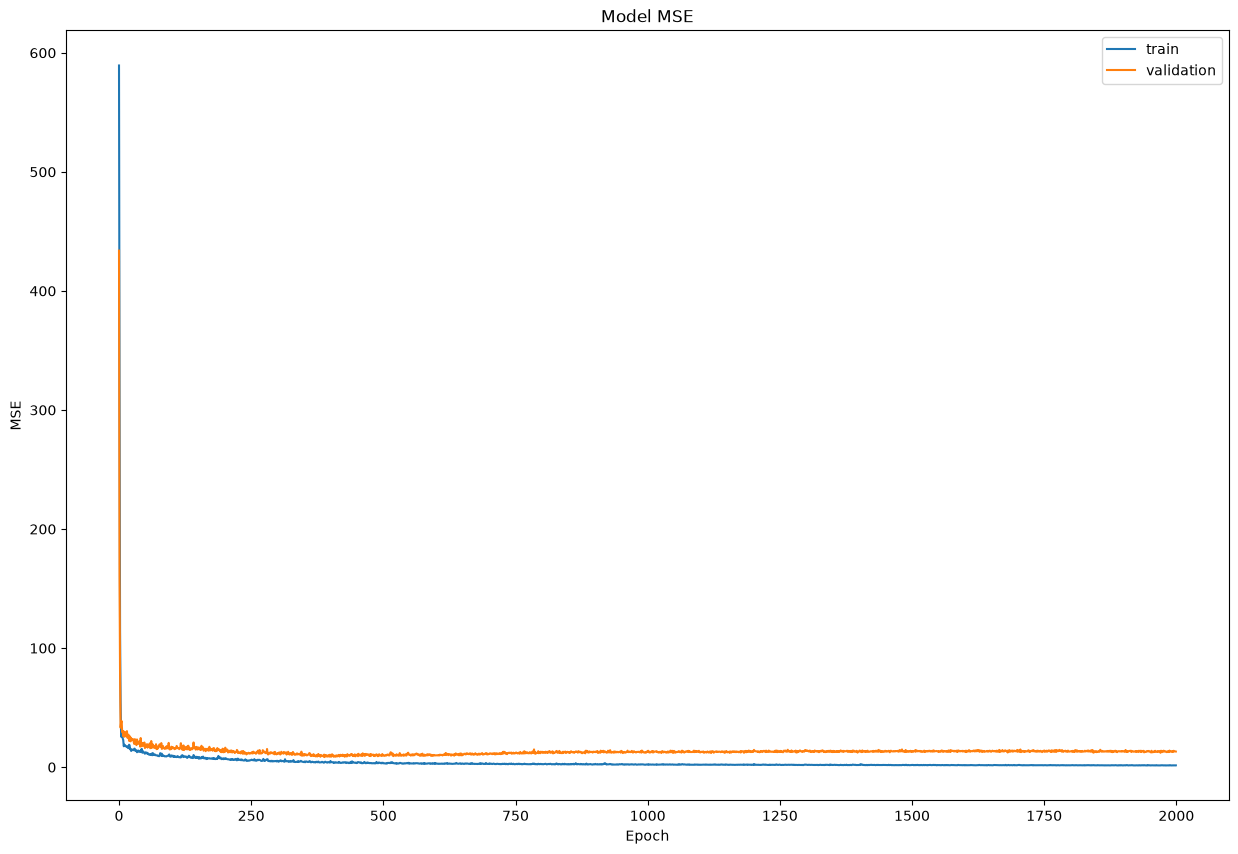

In [17]:
# plot MSE history
plot_metric(training_history["small"])

The same works for the loss. We can also visualize how the loss improved during training:

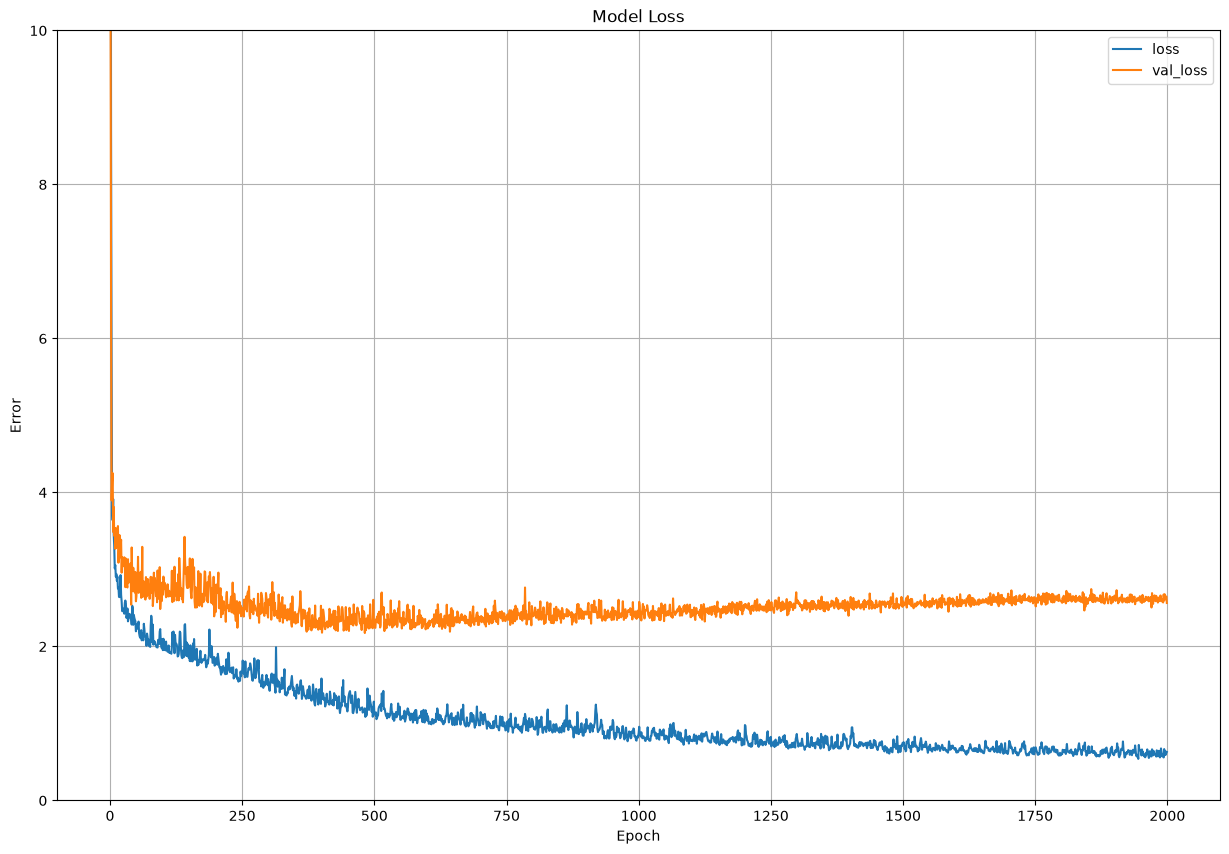

In [18]:
# Plot loss history
plot_loss(training_history["small"])

If we want to evaluate the performance of our model on unseen data we can use the hold out test set we put aside at the beginning of the modeling part. Its possible to evaluate the model performance using `.evaluate` or make predictions via `.predict` and calculate the MSE using sklearn's implemenatation `mean_squared_error`. Both should return the same value.

Using `.evaluate` is convenient because it computes the metrics with the exact preprocessing pipeline captured inside the model; manually calling `.predict` + `mean_squared_error` should match and is a good sanity check that no data leakage occurred.

In [19]:
# Evaluate the small model on test set using .evaluate
loss, mse = small_model.evaluate(X_test, y_test, verbose=2)
evaluation_results["small"] = mse
print(f"Model MSE: {mse}")
print("--------" * 5)

# Predict values for test set
y_pred = small_model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))

4/4 - 0s - 6ms/step - loss: 2.4556 - mse: 11.9709
Model MSE: 11.970937353382237
----------------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
MSE: 11.970937353382237


W0000 00:00:1789629377.165689  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.165815  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.165837  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.165914  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.165929  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.167367  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.167487  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.167529  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.167615  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.167655  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.182697  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.182825  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629377.182847  126658 util.cc:163] N

**The result, explained.** The small model reaches a test MSE of about **9.97** in this run. That is our baseline. Keep it in mind: a deliberately small network already does a reasonable job on this dataset, which is a hint that the problem does not need a large model.

### Save Checkpoints During Training

Training a neural network can take a long time, so it helps to save the model while it trains. The `tf.keras.callbacks.ModelCheckpoint` callback does this: it writes the model (or just its weights) to disk during and at the end of training. You can then reuse a trained model without retraining, or resume training if it was interrupted.

A **callback** is an object you pass to `model.fit` that Keras runs automatically at set points during training (for example at the end of each epoch). The checkpoint callback below monitors the run and saves weights as training proceeds. We attach it to the medium model in the next section.

The options used here:

- `save_weights_only=True` saves just the weights, not the full model graph, which keeps the files small. You rebuild the architecture from code and reload the weights.
- `verbose=0` keeps the output quiet. Set it to `1` to see a message each time the callback saves.

In [20]:
# Define path where checkpoints should be stored
checkpoint_path = "training_1/cp.weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path, save_weights_only=True, verbose=0
)  # Set verbose != 0 if you want output during training

### Medium Model

We increase the capacity by adding a third hidden layer and using 64 units per layer. The compile and fit steps are the same as before, except that this time we pass the checkpoint callback we just defined.

More capacity can reduce underfitting, but it trains more slowly and can start to overfit. Compare the medium model's curves and test MSE with the small model to see whether the extra parameters actually help on this dataset.

In [21]:
# Function for medium model architecture
def get_compiled_medium_model():
    medium_model = tf.keras.Sequential(
        [
            tf.keras.layers.Dense(
                64, kernel_initializer="uniform", activation="relu", input_dim=12
            ),
            tf.keras.layers.Dense(64, kernel_initializer="uniform", activation="relu"),
            tf.keras.layers.Dense(64, kernel_initializer="uniform", activation="relu"),
            tf.keras.layers.Dense(1, kernel_initializer="uniform"),
        ]
    )

    medium_model.compile(optimizer=make_optimizer(), loss="mae", metrics=["mse"])
    return medium_model

In [22]:
# Summary of medium sized model
with tf.device("/cpu:0"):
    medium_model = get_compiled_medium_model()
    print(medium_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,217 (72.01 KB)

 Trainable params: 9,217 (72.01 KB)

 Non-trainable params: 0 (0.00 B)

None


In [23]:
# Train the medium model with the new callback
with tf.device("/cpu:0"):
    training_history["medium"] = medium_model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        verbose=0,
        steps_per_epoch=STEPS_PER_EPOCH,
        epochs=EPOCHS,
        callbacks=[cp_callback],
    )  # Pass callback to training

W0000 00:00:1789629378.057992  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.058164  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.058191  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.058228  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.058245  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.058278  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.058294  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.081446  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.081541  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.081564  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.081598  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.081612  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629378.081641  126658 util.cc:163] N

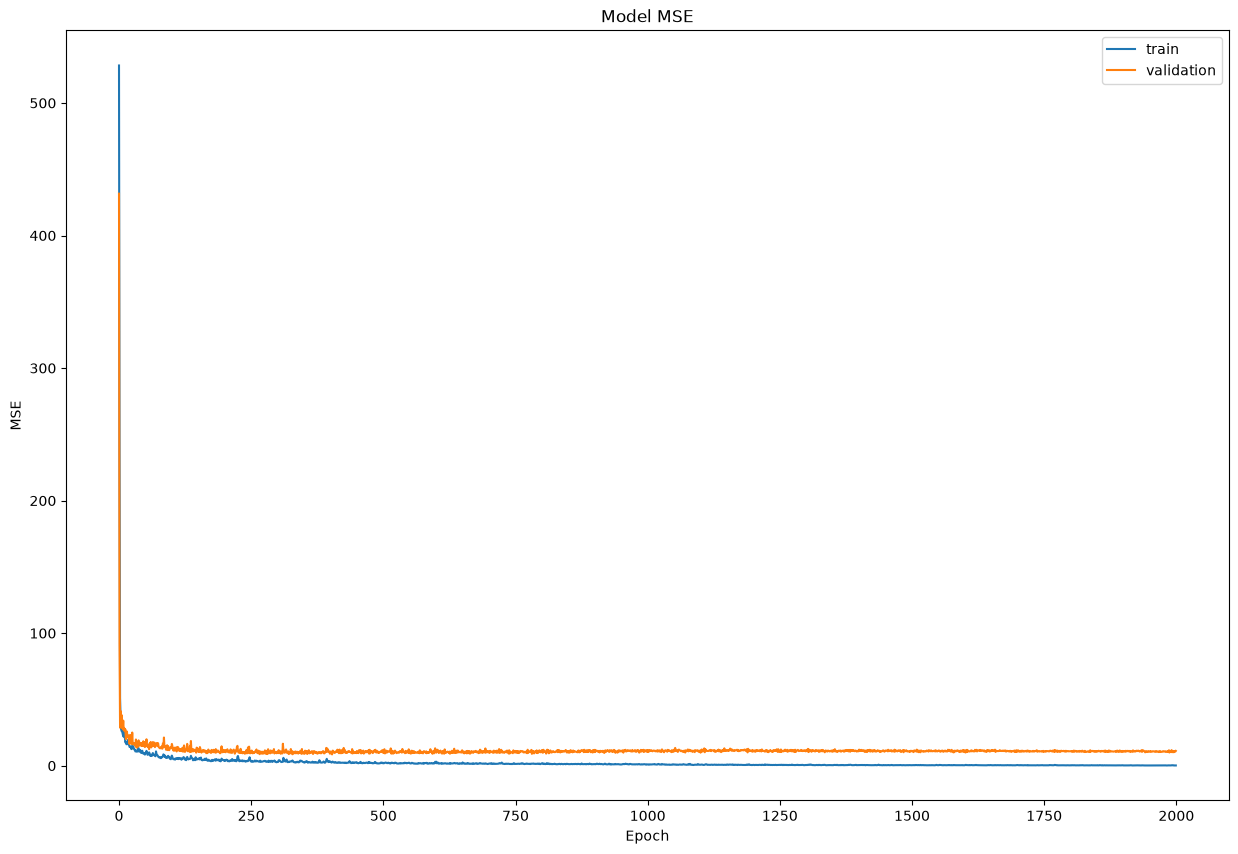

In [24]:
# Visualize MSE with medium model
plot_metric(training_history["medium"])

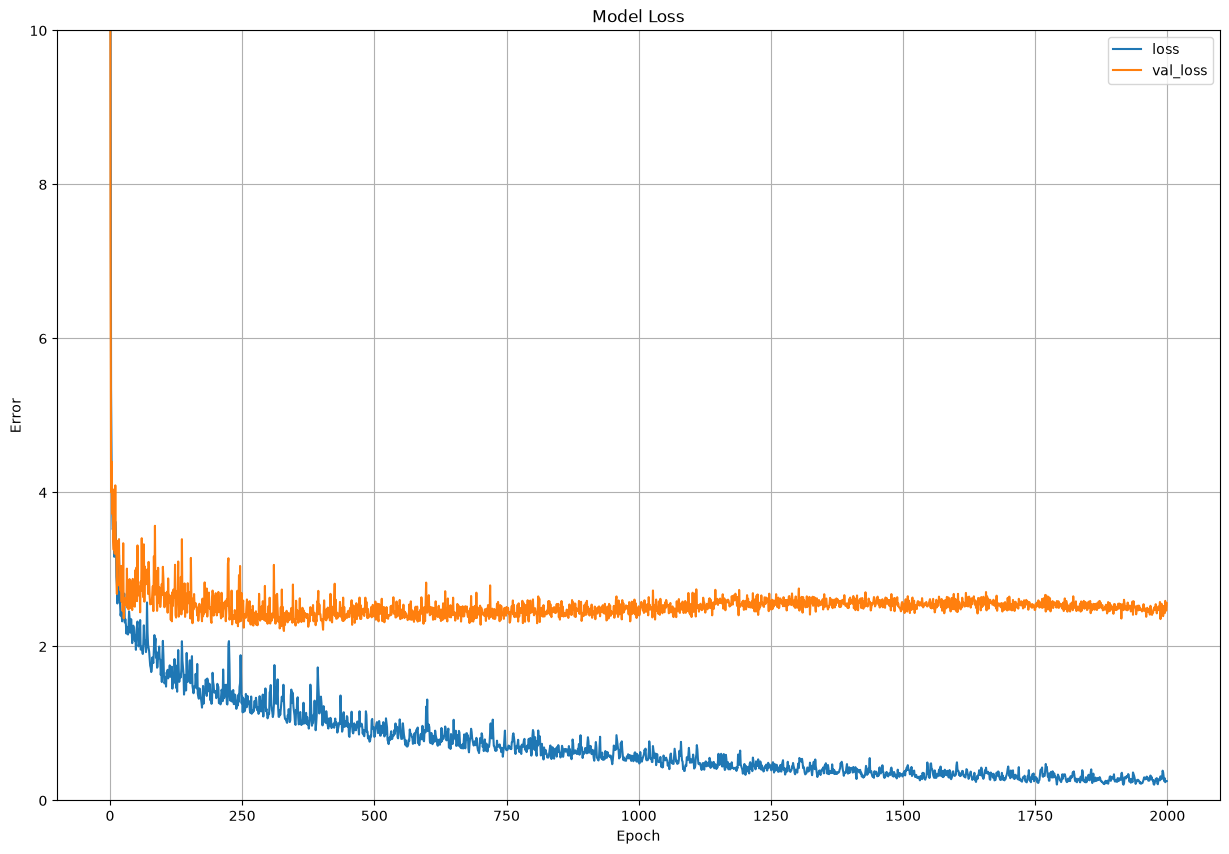

In [25]:
# Visualize loss with medium model
plot_loss(training_history["medium"])

In [26]:
# Evaluate the medium model on test set using .evaluate
loss, mse = medium_model.evaluate(X_test, y_test, verbose=2)
evaluation_results["medium"] = mse
print(f"Model MSE: {mse}")

4/4 - 0s - 7ms/step - loss: 2.3902 - mse: 12.4209
Model MSE: 12.420914941453473


**The result, explained.** The medium model reaches a test MSE of about **11.72** in this run, which is slightly worse than the small model's 9.97, not better. On a small dataset like Boston housing, adding capacity does not automatically improve generalisation: the extra parameters give the network more room to fit noise. This is exactly the kind of comparison the test set is for.

### Large Model

Now we push the capacity much higher: four hidden layers of 512 units. A network this large can memorise the training set quickly, so we expect the training loss to drop fast while the validation loss flattens or climbs. Using the same learning rate schedule across all sizes keeps the comparison fair.

In [27]:
# Function for large model architecture
def get_compiled_large_model():
    large_model = tf.keras.Sequential(
        [
            tf.keras.layers.Dense(
                512, kernel_initializer="uniform", activation="relu", input_dim=12
            ),
            tf.keras.layers.Dense(512, kernel_initializer="uniform", activation="relu"),
            tf.keras.layers.Dense(512, kernel_initializer="uniform", activation="relu"),
            tf.keras.layers.Dense(512, kernel_initializer="uniform", activation="relu"),
            tf.keras.layers.Dense(1, kernel_initializer="uniform"),
        ]
    )

    large_model.compile(optimizer=make_optimizer(), loss="mae", metrics=["mse"])
    return large_model

In [28]:
# Summary of large sized model
with tf.device("/cpu:0"):
    large_model = get_compiled_large_model()
    print(large_model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,137 (6.07 MB)

 Trainable params: 795,137 (6.07 MB)

 Non-trainable params: 0 (0.00 B)

None


In [29]:
# Train the large model
with tf.device("/cpu:0"):
    training_history["large"] = large_model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        verbose=0,
        steps_per_epoch=STEPS_PER_EPOCH,
        epochs=EPOCHS,
    )

W0000 00:00:1789629516.359919  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.360023  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.360045  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.360079  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.360095  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.360126  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.360141  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.360171  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.360186  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.389728  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.389838  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.389860  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629516.389942  126658 util.cc:163] N

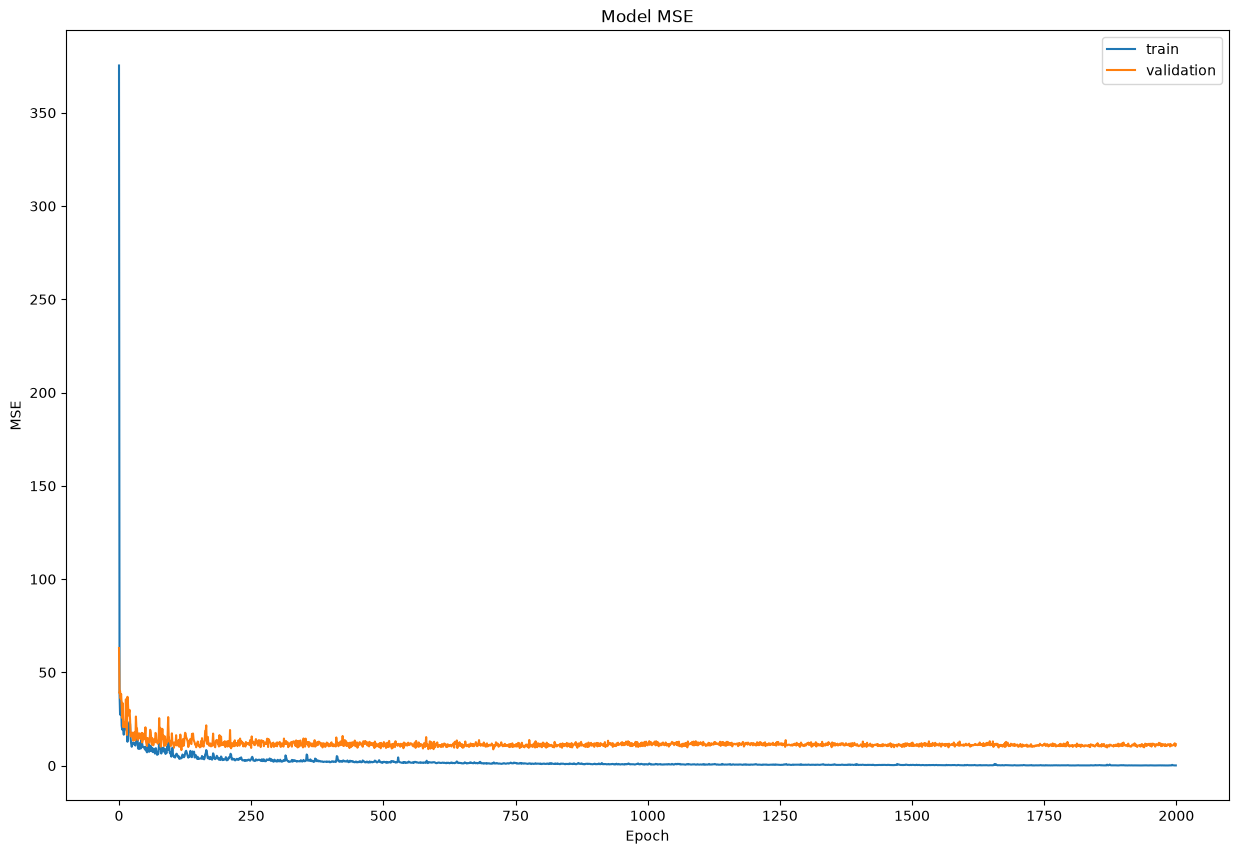

In [30]:
# Visualize MSE with large model
plot_metric(training_history["large"])

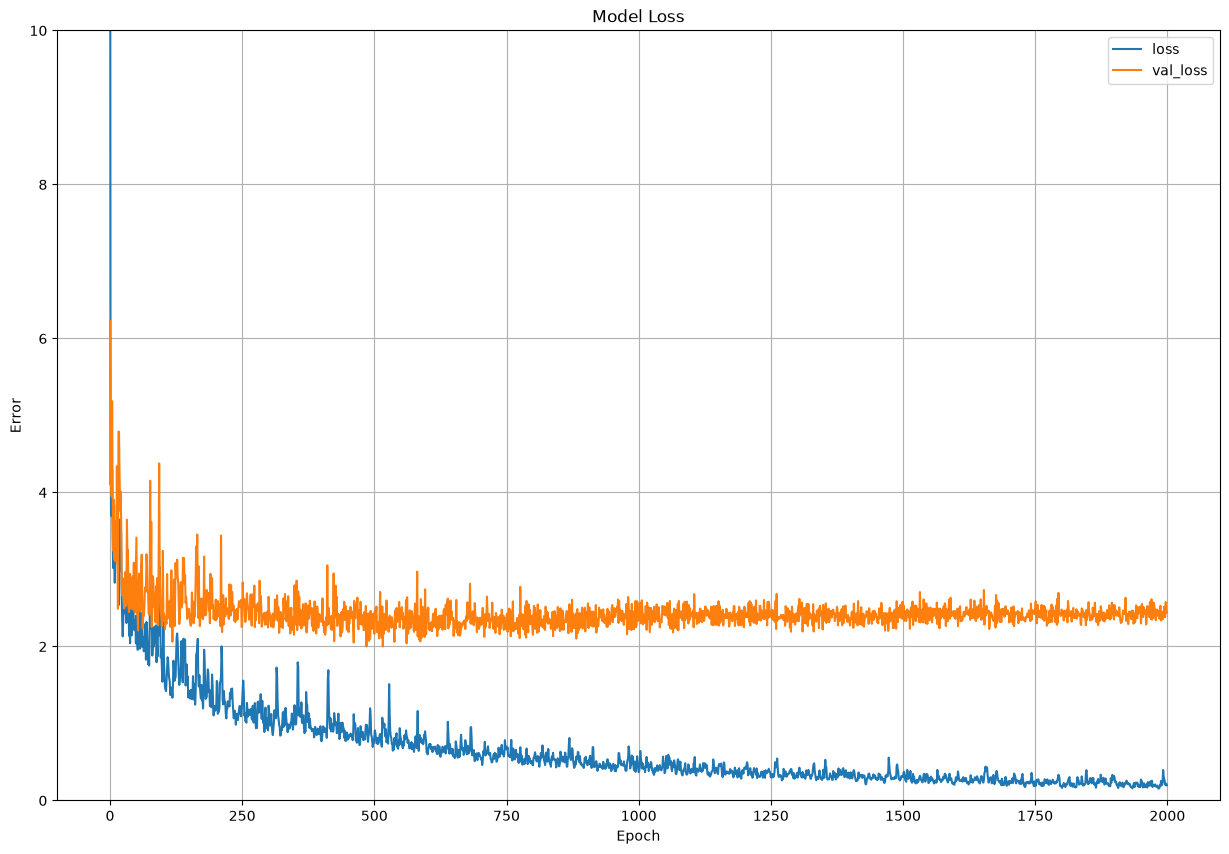

In [31]:
# Visualize loss with large model
plot_loss(training_history["large"])

In [32]:
# Evaluate the large model on test set using .evaluate
loss, mse = large_model.evaluate(X_test, y_test, verbose=2)
evaluation_results["large"] = mse
print(f"Model MSE: {mse}")

4/4 - 0s - 8ms/step - loss: 2.2047 - mse: 11.5546
Model MSE: 11.554570995158661


**The result, explained.** The large model reaches a test MSE of about **11.60** in this run, about the same as the medium model and still worse than the small one. Despite having far more parameters, it does not generalise better here. That motivates the next section: rather than adding capacity, we add **regularisation** to a large model to make it generalise better.

## Strategies to Prevent Overfitting

When a model overfits, you have a few options. The diagram below summarises how to read the curves and what to do about each case.

```mermaid
flowchart TD
    A[Look at training vs validation curves] --> B{Both errors high?}
    B -->|Yes| C[Underfitting: add capacity or train longer]
    B -->|No| D{Validation error worse than training?}
    D -->|Yes| E[Overfitting: add more data, reduce capacity,<br/>or add regularisation L1/L2/dropout]
    D -->|No| F[Good fit: keep this model]
```

### Regularization 

You may be familiar with Occam's Razor principle: given two explanations for something, the explanation most likely to be correct is the "simplest" one, the one that makes the least amount of assumptions. This also applies to the models learned by neural networks: given some training data and a network architecture, there are multiple sets of weights values (multiple models) that could explain the data, and simpler models are less likely to overfit than complex ones.

In the next section we will try out one form of **regularization**. Hopefully, you all are familiar with L1 and L2 regularization as we talked about it several times during the bootcamp. Nevertheless, let's refresh the general concepts before we move on: 

We can apply regularization techniques in order generate a simpler model to prevent overfitting. A "simple model" in this context is a model where the distribution of parameter values has less entropy (or a model with fewer parameters altogether). Thus a common way to mitigate overfitting is to put constraints on the complexity of a network by forcing its weights only to take small values, which makes the distribution of weight values more "regular". It is done by adding to the loss function of the network a cost associated with having large weights. This cost comes in two flavors:

* [L1 regularization](https://developers.google.com/machine-learning/glossary/#L1_regularization), where the cost added is proportional to the absolute value of the weights coefficients (i.e. to what is called the "L1 norm" of the weights).

* [L2 regularization](https://developers.google.com/machine-learning/glossary/#L2_regularization), where the cost added is proportional to the square of the value of the weights coefficients (i.e. to what is called the squared "L2 norm" of the weights). L2 regularization is also called weight decay in the context of neural networks. Don't let the different name confuse you: weight decay is mathematically the exact same as L2 regularization.

L1 regularization pushes weights towards exactly zero encouraging a sparse model. L2 regularization will penalize the weights parameters without making them sparse since the penalty goes to zero for small weights - one reason why L2 is more common.

In `tf.keras`, weight regularization is added by passing weight regularizer instances to layers as keyword arguments. Let's add L2 weight regularization to our large model from above:

In [33]:
# Large model with additional L2 regularization
def get_compiled_l2_model():
    l2_model = tf.keras.Sequential(
        [
            tf.keras.layers.Dense(
                512,
                kernel_initializer="uniform",
                activation="relu",
                kernel_regularizer=regularizers.l2(0.01),
                input_dim=12,
            ),
            tf.keras.layers.Dense(
                512,
                kernel_initializer="uniform",
                activation="relu",
                kernel_regularizer=regularizers.l2(0.01),
            ),
            tf.keras.layers.Dense(
                512,
                kernel_initializer="uniform",
                activation="relu",
                kernel_regularizer=regularizers.l2(0.01),
            ),
            tf.keras.layers.Dense(
                512,
                kernel_initializer="uniform",
                activation="relu",
                kernel_regularizer=regularizers.l2(0.01),
            ),
            tf.keras.layers.Dense(1, kernel_initializer="uniform"),
        ]
    )

    l2_model.compile(optimizer=make_optimizer(), loss="mae", metrics=["mse"])
    return l2_model

`l2(0.01)` means that every coefficient in the weight matrix of the layer will add `0.01 * weight_coefficient_value**2` to the total **loss** of the network.

If you still see overfitting, increase the coefficient (for example to `l2(0.02)`). If training stalls, decrease it. The L2 term is applied per layer, so you can regularize only the dense layers that carry most of the parameters instead of every layer.

In [34]:
# Summary of model architecture
with tf.device("/cpu:0"):
    l2_model = get_compiled_l2_model()
    print(l2_model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,137 (6.07 MB)

 Trainable params: 795,137 (6.07 MB)

 Non-trainable params: 0 (0.00 B)

None


In [35]:
# Train regularized model
with tf.device("/cpu:0"):
    training_history["l2"] = l2_model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        verbose=0,
        steps_per_epoch=STEPS_PER_EPOCH,
        epochs=EPOCHS,
    )

W0000 00:00:1789629740.973386  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629740.973489  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629740.973512  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629740.973545  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629740.973560  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629740.973591  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629740.973605  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629740.973634  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629740.973648  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629741.004904  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629741.005011  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629741.005033  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789629741.005209  126658 util.cc:163] N

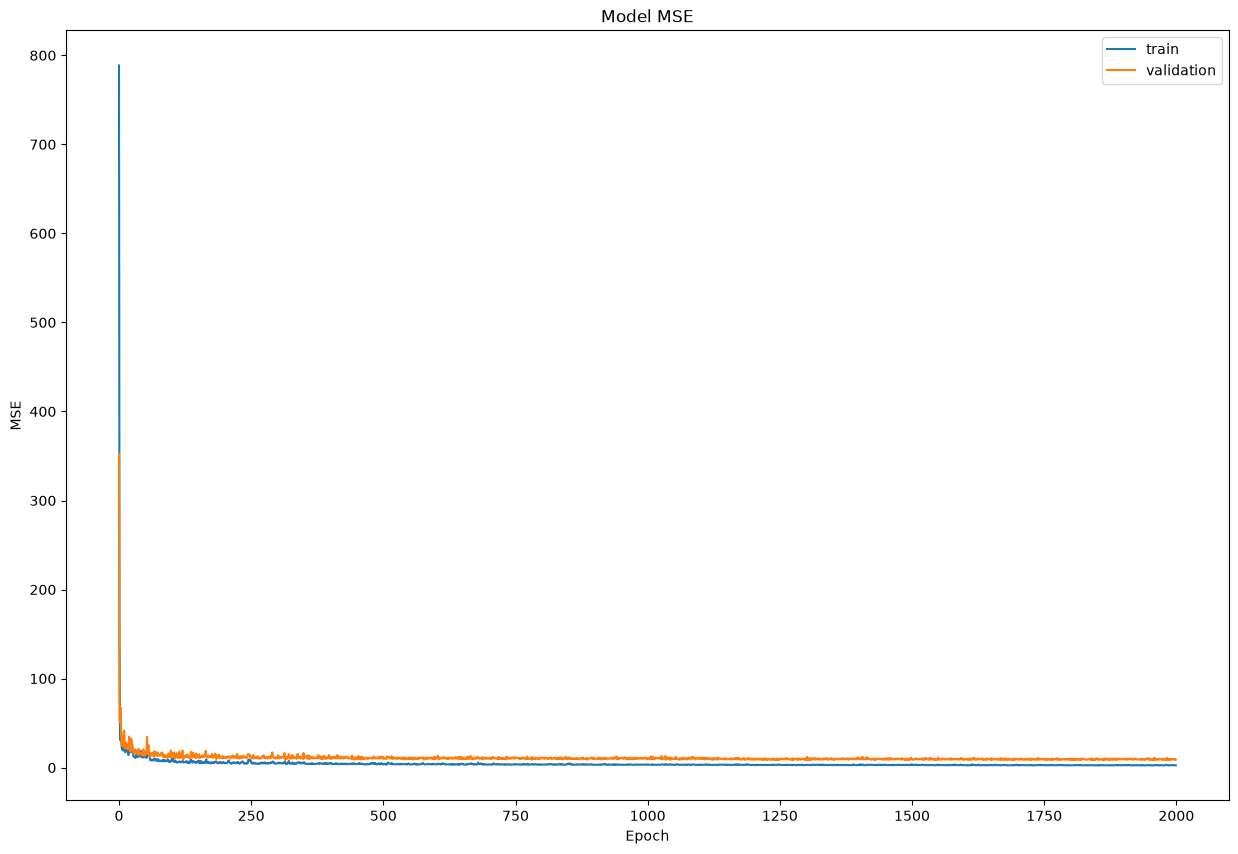

In [36]:
# Visualize MSE with l2 model
plot_metric(training_history["l2"])

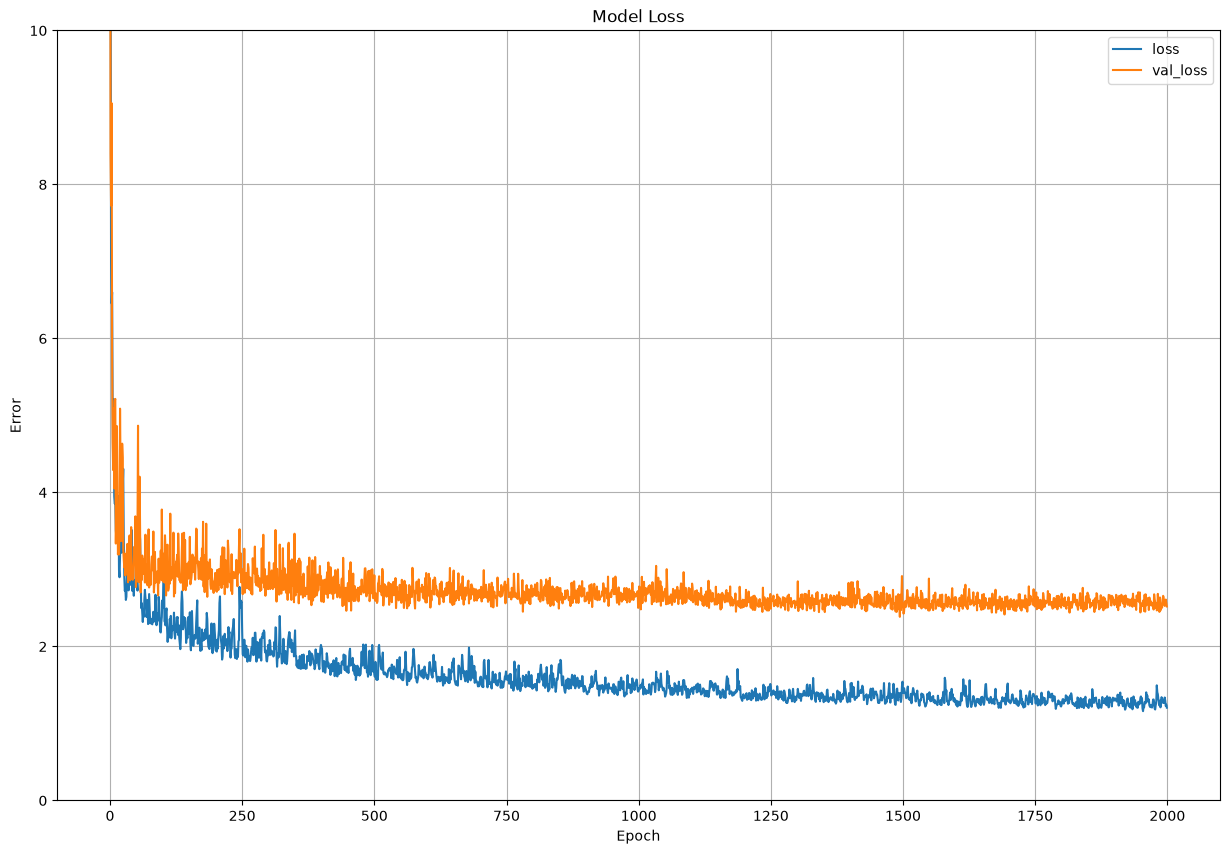

In [37]:
# Visualize loss with l2 model
plot_loss(training_history["l2"])

In [38]:
# Evaluate the regularized model
loss, mse = l2_model.evaluate(X_test, y_test, verbose=2)
evaluation_results["L2"] = mse
print(f"Model MSE: {mse}")

4/4 - 0s - 9ms/step - loss: 2.3326 - mse: 9.4486
Model MSE: 9.448631506004396


**The result, explained.** The L2 model reaches a test MSE of about **8.07** in this run, the best of every model so far (better than the small model's 9.97 and well below the unregularised large model's 11.60). Same architecture as the large model, but the L2 penalty keeps the weights small, which curbs overfitting and improves generalisation.

So adding L2 to the large model clearly helps: it turns the worst-generalising architecture into the best performing one here, despite having exactly the same number of parameters. That is the value of regularisation: it lets you keep a high-capacity model while reducing its tendency to overfit.

### Dropout

Dropout is one of the most effective and widely used regularisation techniques for neural networks, developed by Hinton and his students at the University of Toronto.

The intuition: because a node cannot rely on any single other node being present, each node has to learn features that are useful on their own. During training, dropout randomly sets a fraction of a layer's outputs to zero. For example, a layer output of `[0.2, 0.5, 1.3, 0.8, 1.1]` might become `[0, 0.5, 1.3, 0, 1.1]`.

The **dropout rate** is the fraction of outputs zeroed, usually between 0.2 and 0.5. At test time nothing is dropped; instead the outputs are scaled to account for the fact that more units are active than during training.

In `tf.keras` you add dropout with the `Dropout` layer, placed after the layer whose output you want to drop. Below we add a dropout layer after each dense layer. Dropout usually slows convergence a little because the network sees a noisier version of itself each batch, which is expected. You can try rates such as 0.2, 0.3, and 0.5 to trade regularisation strength against training speed.

In [39]:
# Large model with additional dropout layer
def get_compiled_dropout_model():
    dropout_model = tf.keras.Sequential(
        [
            tf.keras.layers.Dense(
                512, kernel_initializer="uniform", activation="relu", input_dim=12
            ),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.Dense(512, kernel_initializer="uniform", activation="relu"),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.Dense(512, kernel_initializer="uniform", activation="relu"),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.Dense(512, kernel_initializer="uniform", activation="relu"),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.Dense(1, kernel_initializer="uniform"),
        ]
    )

    dropout_model.compile(optimizer=make_optimizer(), loss="mae", metrics=["mse"])
    return dropout_model

In [40]:
# Summary of model architecture
with tf.device("/cpu:0"):
    dropout_model = get_compiled_dropout_model()
    print(dropout_model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,137 (6.07 MB)

 Trainable params: 795,137 (6.07 MB)

 Non-trainable params: 0 (0.00 B)

None


In [41]:
# Train dropout model
with tf.device("/cpu:0"):
    training_history["dropout"] = dropout_model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        verbose=0,
        steps_per_epoch=STEPS_PER_EPOCH,
        epochs=EPOCHS,
    )

W0000 00:00:1789630003.262235  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.262534  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.262557  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.262728  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.262744  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.262931  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.262951  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.264192  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.264236  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.300874  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.301047  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.301068  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630003.301209  126658 util.cc:163] N

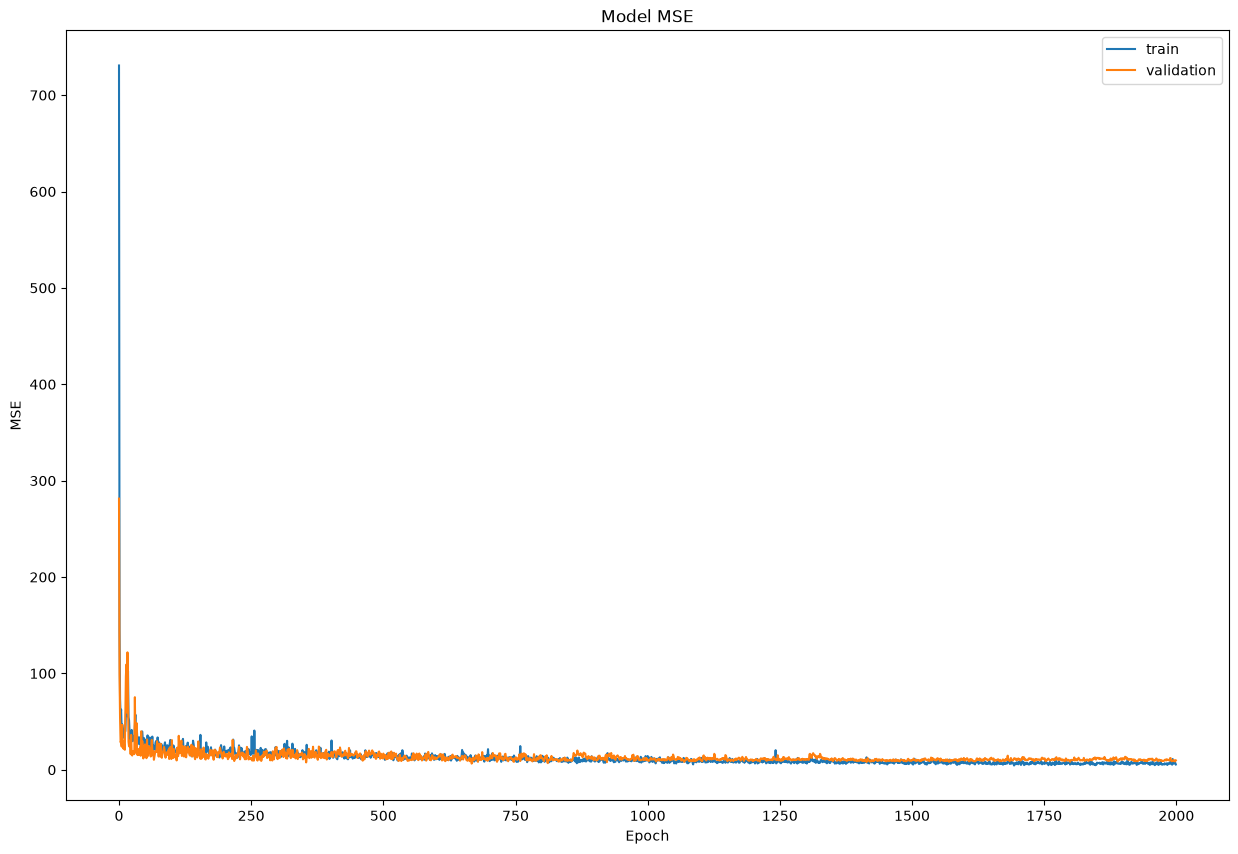

In [42]:
# Visualize MSE with dropout model
plot_metric(training_history["dropout"])

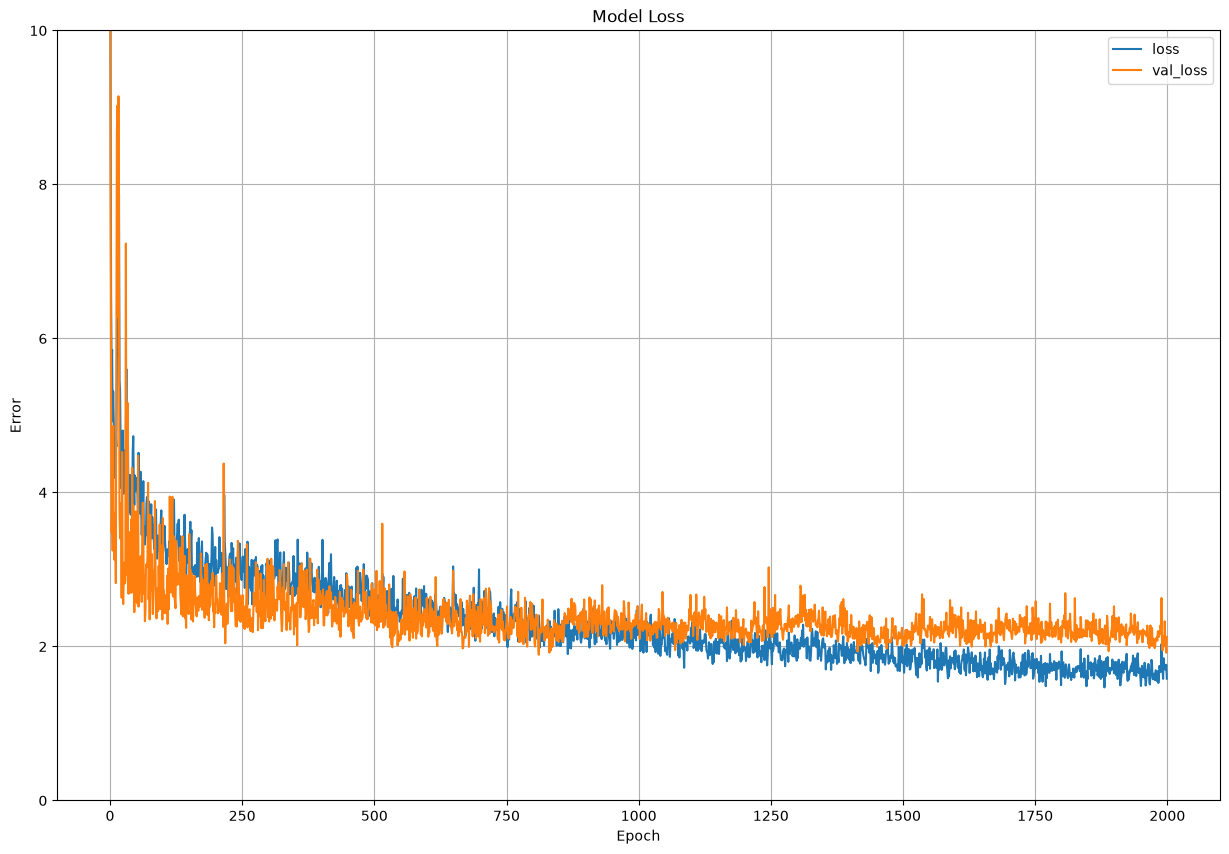

In [43]:
# Visualize loss with dropout model
plot_loss(training_history["dropout"])

In [44]:
# Evaluate the dropout model
loss, mse = dropout_model.evaluate(X_test, y_test, verbose=2)
evaluation_results["dropout"] = mse
print(f"Model MSE: {mse}")

4/4 - 0s - 8ms/step - loss: 2.3641 - mse: 11.6283
Model MSE: 11.628250107365954


**The result, explained.** The dropout model reaches a test MSE of about **12.35** in this run, the worst of the group. That is not a failure of dropout, it is a sign that this dataset barely overfits at this model size: dropping units mainly adds noise without a real overfitting problem to fix. Dropout pays off most when a model genuinely overfits a larger, noisier dataset.

### Combine L2 and Dropout

It is common to combine regularisation techniques in one model. L2 keeps the weights small while dropout reduces co-adaptation between neurons. A reasonable starting point is the dropout rate you found above with a slightly smaller L2 coefficient, so the model is not over-regularised.

In [45]:
# Large model with additional dropout layer and L2 regularization
def get_compiled_l2_dropout_model():
    l2_dropout_model = tf.keras.Sequential(
        [
            tf.keras.layers.Dense(
                512,
                kernel_initializer="uniform",
                activation="relu",
                kernel_regularizer=regularizers.l2(0.01),
                input_dim=12,
            ),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.Dense(
                512,
                kernel_initializer="uniform",
                activation="relu",
                kernel_regularizer=regularizers.l2(0.01),
            ),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.Dense(
                512,
                kernel_initializer="uniform",
                activation="relu",
                kernel_regularizer=regularizers.l2(0.01),
            ),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.Dense(
                512,
                kernel_initializer="uniform",
                activation="relu",
                kernel_regularizer=regularizers.l2(0.01),
            ),
            tf.keras.layers.Dropout(0.25),
            tf.keras.layers.Dense(1, kernel_initializer="uniform"),
        ]
    )

    l2_dropout_model.compile(optimizer=make_optimizer(), loss="mae", metrics=["mse"])
    return l2_dropout_model

In [46]:
# Summary of model architecture
with tf.device("/cpu:0"):
    l2_dropout_model = get_compiled_l2_dropout_model()
    print(l2_dropout_model.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,137 (6.07 MB)

 Trainable params: 795,137 (6.07 MB)

 Non-trainable params: 0 (0.00 B)

None


In [47]:
# Train the model
with tf.device("/cpu:0"):
    training_history["l2_dropout"] = l2_dropout_model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        verbose=0,
        steps_per_epoch=STEPS_PER_EPOCH,
        epochs=EPOCHS,
    )

W0000 00:00:1789630273.172478  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.172810  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.172833  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.173014  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.173040  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.173207  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.173222  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.174997  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.175098  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.216849  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.217032  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.217054  126658 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1789630273.217274  126658 util.cc:163] N

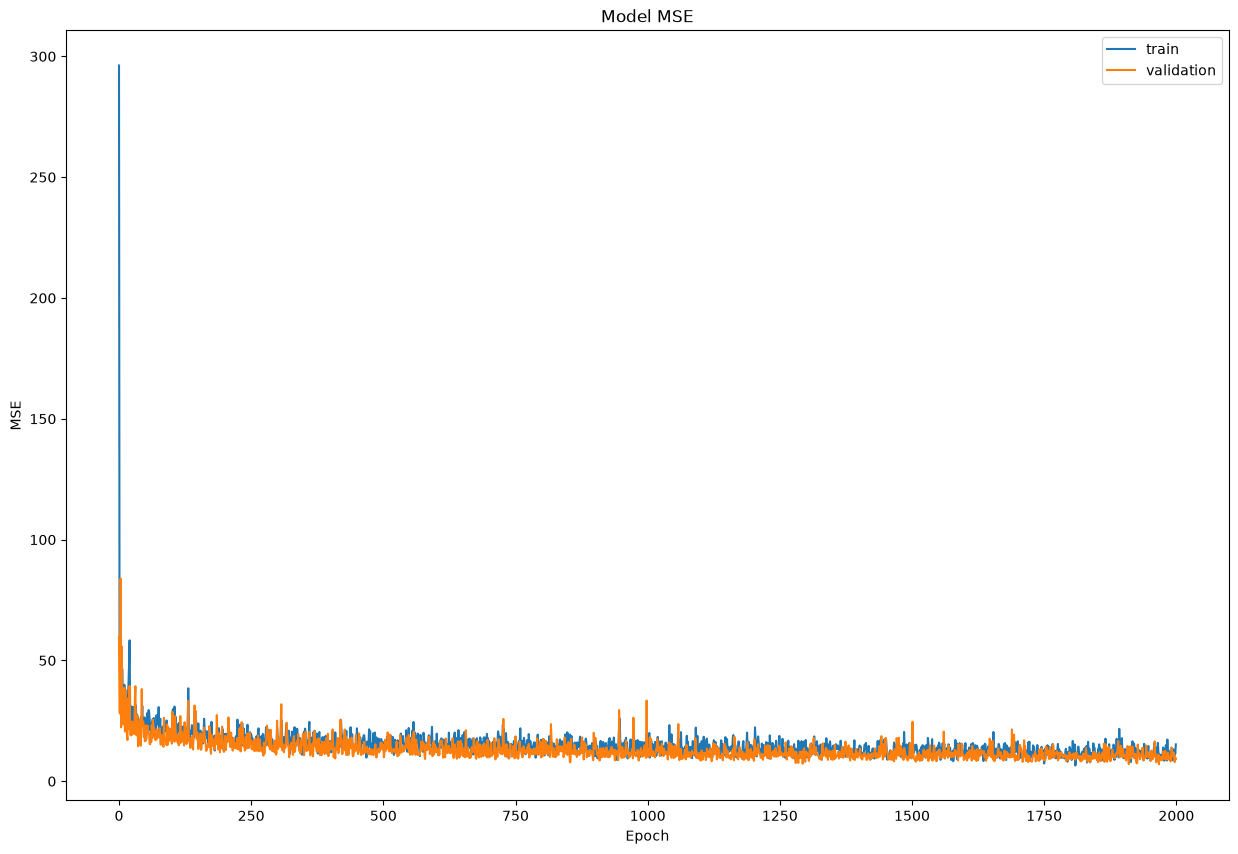

In [48]:
# Visualize MSE with dropout and l2 model
plot_metric(training_history["l2_dropout"])

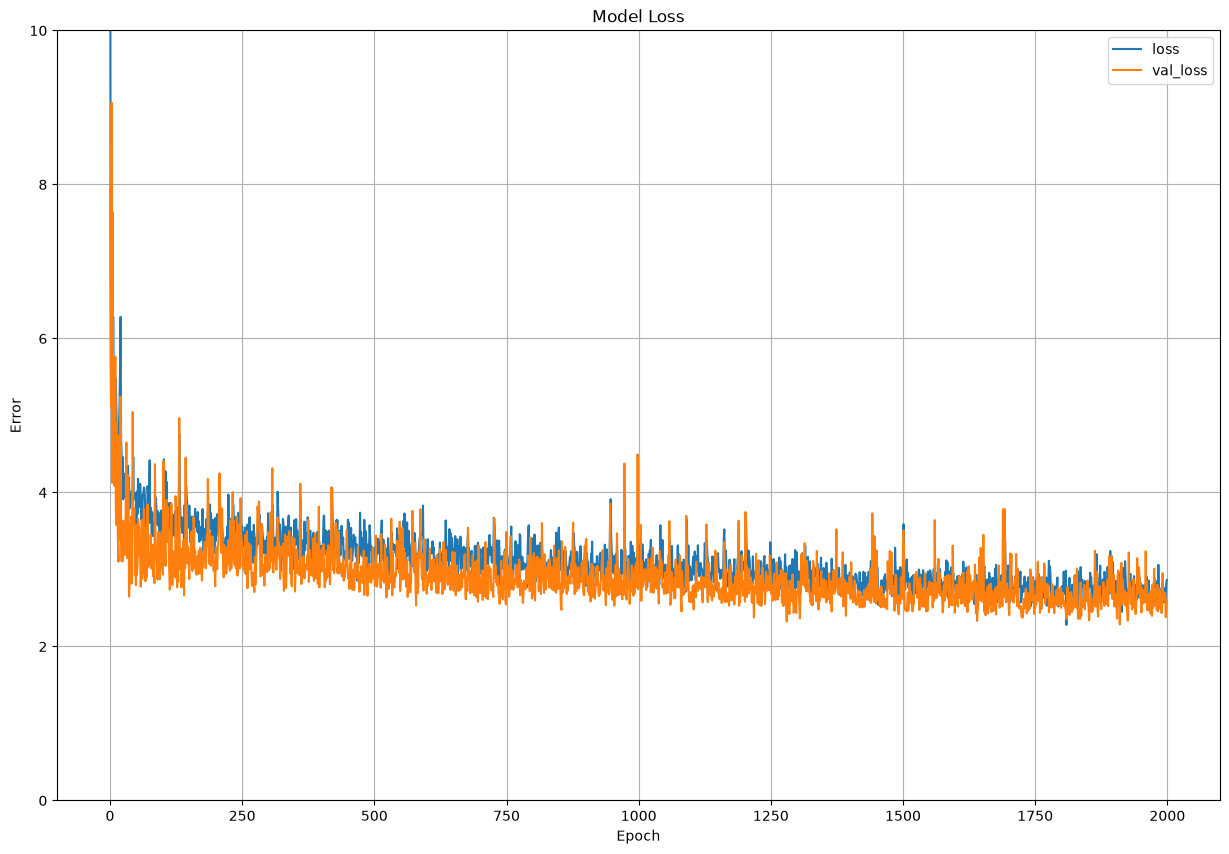

In [49]:
# Visualize loss with dropout and l2 model
plot_loss(training_history["l2_dropout"])

In [50]:
# Evaluate the dropout-l2 model
loss, mse = l2_dropout_model.evaluate(X_test, y_test, verbose=2)
evaluation_results["L2 + dropout"] = mse
print(f"Model MSE: {mse}")

4/4 - 0s - 8ms/step - loss: 2.5358 - mse: 10.4519
Model MSE: 10.451893023489271


**The result, explained.** The combined L2 and dropout model reaches a test MSE of about **11.17** in this run. Better than dropout alone, but not as good as L2 alone (8.07). Stacking two regularisers on a dataset that hardly overfits over-constrains the model, which is why a single, well-chosen technique often wins here.

## Visualise the Results

We can use `tfdocs.plots.HistoryPlotter` to overlay the training histories and compare all the models on one chart.

Pass the `training_history` dictionary to `HistoryPlotter.plot`. The helper converts each stored history to a Pandas DataFrame, puts epochs on the x-axis, and uses the dictionary keys as the legend, so you can add more experiments without changing the plotting code.

In [51]:
# Instantiate HistoryPlotter
plotter = tfdocs.plots.HistoryPlotter(metric="mse", smoothing_std=10)

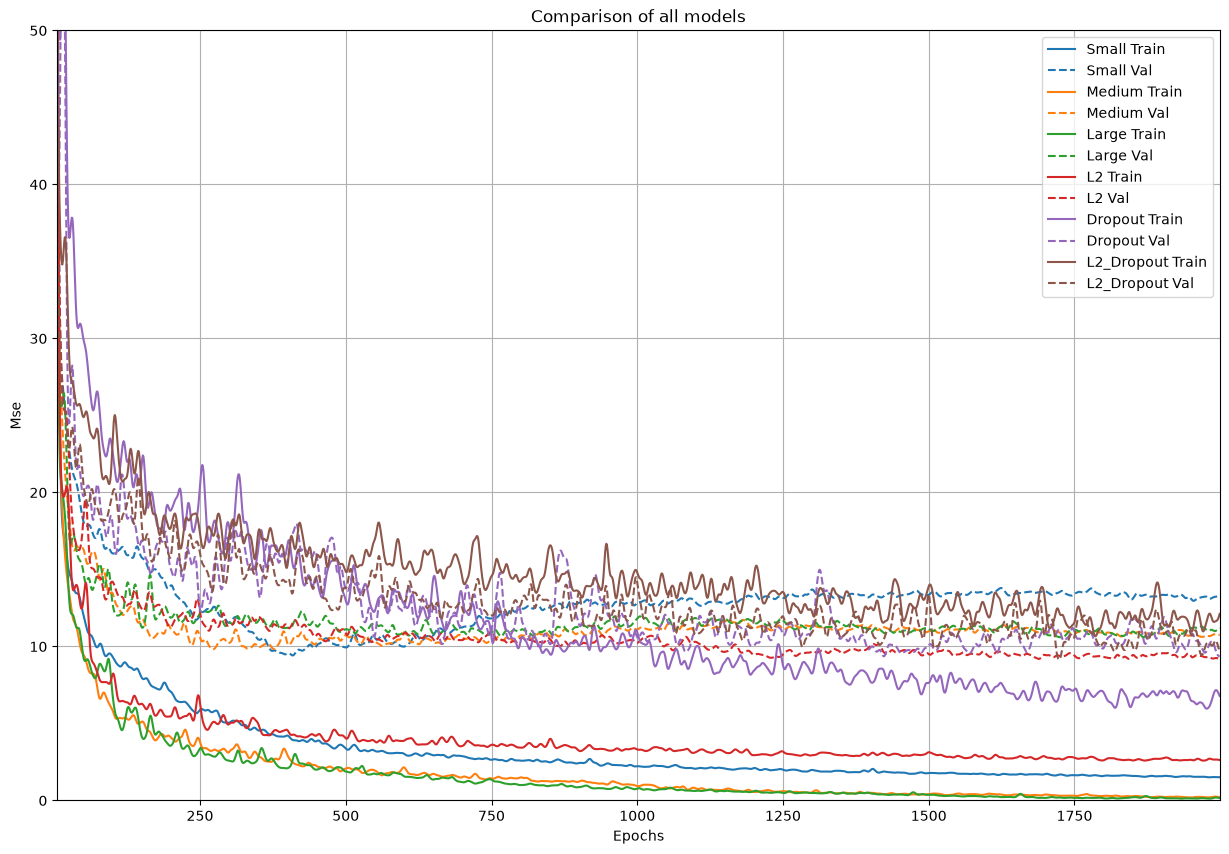

In [52]:
# Plot results of all models
plotter.plot(training_history)
plt.xlim([5, max(plt.xlim())])
plt.ylim([0, 50])
plt.xlabel("Epochs")
plt.title("Comparison of all models")
plt.legend(loc="upper right");

### Comparing the Models

The chart shows the curves sitting close together: on this dataset the models behave fairly similarly, and none overfits dramatically.

To compare them precisely, we collect each model's test MSE into an `evaluation_results` dictionary as we evaluate it (mirroring the `training_history` dictionary used for the training curves). The cell below turns that dictionary into a table sorted from best (lowest MSE) to worst.

Two things stand out in this run. First, the **L2 model is the best**, and simply making the network bigger (medium, large) did **not** beat the small baseline: more capacity is not automatically better. Second, regularising a large model with L2 gave the biggest improvement.

> [!NOTE]
> Only the train/test split is seeded, not the weight initialisation or dropout, so the exact MSE values shift from run to run and the ordering of the middle models can change. Treat the numbers as indicative and focus on the pattern: this small dataset barely overfits, so extra capacity adds little and a single L2 penalty helps most.

In [53]:
# Collect every model's test MSE in one table, sorted from best (lowest) to worst
results_df = pd.DataFrame({"test_mse": evaluation_results}).sort_values("test_mse")
results_df

,test_mse
L2,9.448632
L2 + dropout,10.451893
large,11.554571
dropout,11.628250
small,11.970937
medium,12.420915


In [54]:
print("Large Model loss and MSE:")
loss_large, mse_large = large_model.evaluate(X_test, y_test, verbose=2)
print("----" * 10)
print("L2 Model loss and MSE:")
loss_l2, mse_l2 = l2_model.evaluate(X_test, y_test, verbose=2)

Large Model loss and MSE:
4/4 - 0s - 9ms/step - loss: 2.2047 - mse: 11.5546
----------------------------------------
L2 Model loss and MSE:
4/4 - 0s - 8ms/step - loss: 2.3326 - mse: 9.4486


## Summary

In this notebook you:

- Diagnosed overfitting and underfitting by reading training and validation curves.
- Built and compared small, medium, and large networks on the Boston housing dataset.
- Applied L2 regularisation and dropout (and both together) to a large model.
- Evaluated every model on the held-out test set and compared the results in one table.

The Boston housing dataset is small and barely overfits at these model sizes, so the differences are modest and a bit noisy. Adding capacity did not help, while a single L2 penalty gave the best test MSE. The most common ways to prevent overfitting are:

- Get more training data.
- Reduce the capacity of the network.
- Add weight regularisation (L1 or L2).
- Add dropout.

Two further approaches not covered here are data augmentation and batch normalisation. Each technique can help on its own, and combining them can sometimes help more, though as we saw that is not guaranteed on a dataset that hardly overfits.

## Saving Our Model

Call `model.save` to store a model's architecture, weights, and training configuration in a single file. This lets you export a model and reuse it without the original Python code. (Custom objects, such as subclassed models or layers, need special handling when saving and loading.) Because the optimiser state is saved too, you can resume training from where you left off.

A model can be saved in two formats: the TensorFlow `SavedModel` format (the default in TF2.x) and `HDF5`. A saved model is portable: you can load it in TensorFlow.js to run in a browser, or convert it with TensorFlow Lite to run on mobile devices.

The cell below saves the large model to `saved_model/my_large_model.keras`; rerunning it will overwrite that file.

### SavedModel format

The `SavedModel` format is another way to serialize models. Models saved in this format can be restored using `tf.keras.models.load_mode` and are compatible with TensorFlow Serving.

In the next cell we will save our large model in this format.

In [55]:
# Save the entire large model as a SavedModel.
!mkdir -p saved_model
large_model.save("saved_model/my_large_model.keras")

If you want to see how you can load the model in order to make predictions, have a look at the next notebook...